In [1]:
import os
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
INPUT_DIR  = 'png_images/kaggle/working/png_images'       # your existing PNG output folder
OUTPUT_DIR = 'png_images/kaggle/working/preprocessed_images'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_SIZE = (512, 512)

files = os.listdir(INPUT_DIR)
print(f"Found {len(files)} PNG images")

Found 50 PNG images


Preprocessing: 100%|██████████| 50/50 [00:07<00:00,  6.76it/s]



✅ Done! Saved to png_images/kaggle/working/preprocessed_images


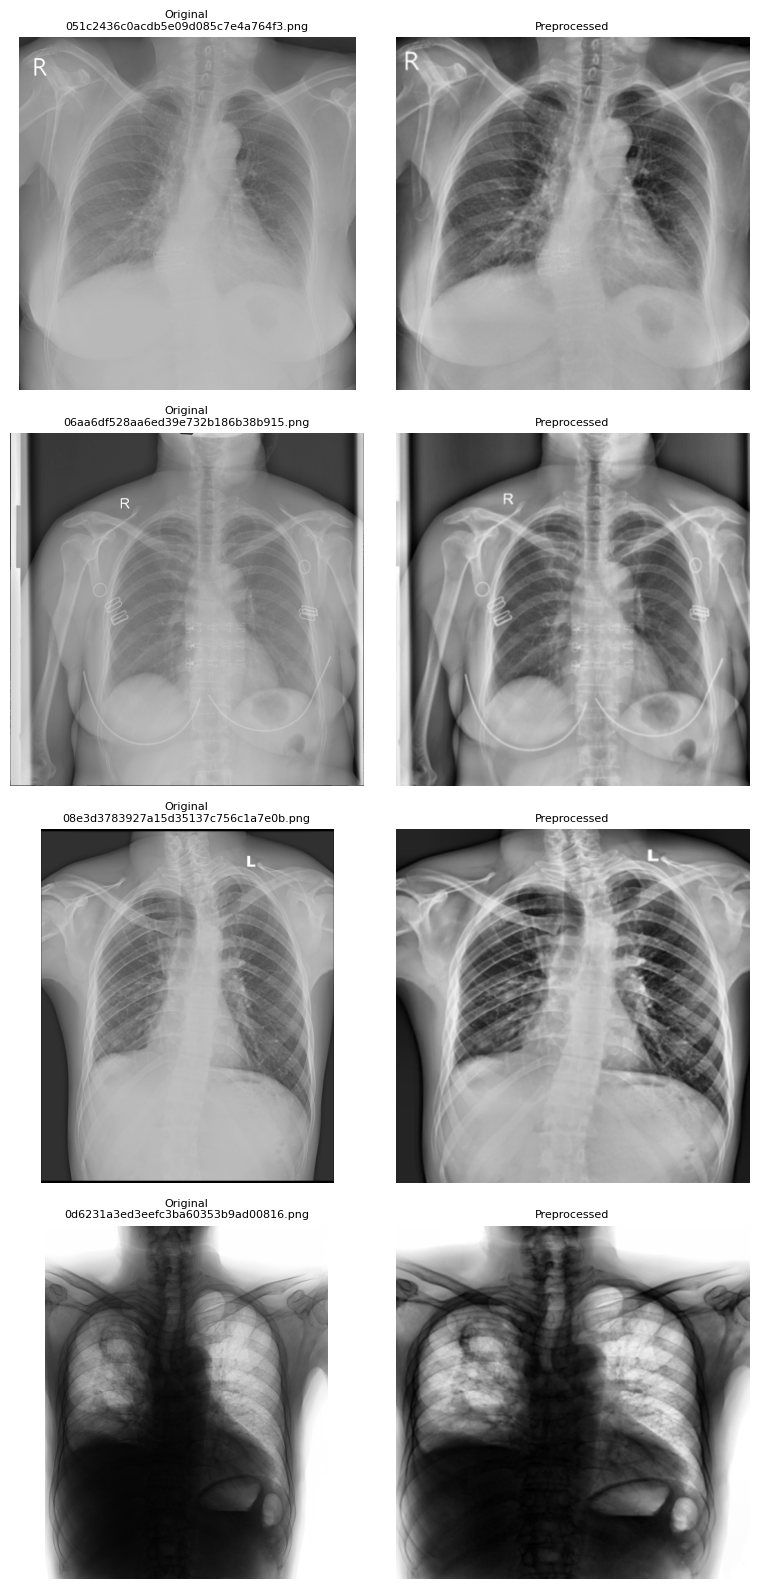

In [3]:
for file in tqdm(files, desc="Preprocessing"):
    img_path = os.path.join(INPUT_DIR, file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)   # load as grayscale directly
    
    if img is None:
        print(f"[SKIP] Could not load: {file}")
        continue

    # Step 1 – Crop borders (2%)
    h, w = img.shape
    top, bottom = int(h * 0.02), int(h * 0.98)
    left, right = int(w * 0.02), int(w * 0.98)
    img = img[top:bottom, left:right]

    # Step 2 – Resize
    img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    # Step 3 – Min-Max Normalization (consistent with your DICOM conversion style)
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    img = np.uint8(img)

    # Step 4 – CLAHE (light contrast enhancement)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # Step 5 – Light denoising (Gaussian blur)
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Step 6 – Padding to ensure exact TARGET_SIZE
    h, w = img.shape
    pad_top    = (TARGET_SIZE[0] - h) // 2
    pad_bottom = TARGET_SIZE[0] - h - pad_top
    pad_left   = (TARGET_SIZE[1] - w) // 2
    pad_right  = TARGET_SIZE[1] - w - pad_left
    img = cv2.copyMakeBorder(img, max(pad_top,0), max(pad_bottom,0),
                                  max(pad_left,0), max(pad_right,0),
                             cv2.BORDER_CONSTANT, value=0)

    # Save
    save_path = os.path.join(OUTPUT_DIR, file)
    cv2.imwrite(save_path, img)

print(f"\n✅ Done! Saved to {OUTPUT_DIR}")


# ── VISUAL CHECK (before vs after for 4 images) ───────────────────────────────
sample_files = os.listdir(INPUT_DIR)[:4]
fig, axes = plt.subplots(4, 2, figsize=(8, 16))

for i, file in enumerate(sample_files):
    original  = cv2.imread(os.path.join(INPUT_DIR, file),  cv2.IMREAD_GRAYSCALE)
    processed = cv2.imread(os.path.join(OUTPUT_DIR, file), cv2.IMREAD_GRAYSCALE)

    axes[i][0].imshow(original,  cmap='gray')
    axes[i][0].set_title(f"Original\n{file}", fontsize=8)
    axes[i][0].axis('off')

    axes[i][1].imshow(processed, cmap='gray')
    axes[i][1].set_title("Preprocessed", fontsize=8)
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

Images with findings : 16
Total annotations    : 134
✅ YOLO labels saved to png_images/kaggle/working/yolo_labels/
✅ dataset.yaml saved to /kaggle/working/


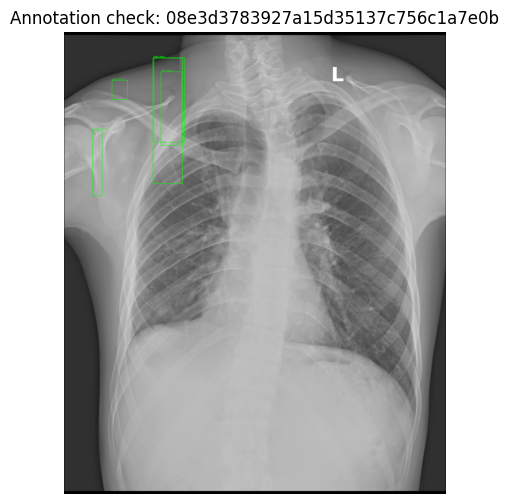

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ANNOTATION CONVERSION — CSV to YOLO Format
# ═══════════════════════════════════════════════════════════════════════════════
import os
import pandas as pd
from pathlib import Path


CSV_PATH    = 'png_images/kaggle//working/vinbigdata-chest-xray-abnormalities-detection/train.csv'
PNG_DIR     = 'png_images/kaggle/working/png_images'
YOLO_DIR    = 'png_images/kaggle/working/yolo_labels'
TARGET_SIZE = (512, 512)      
ORIG_SIZE   = (1024, 1024)    # VinBigData original DICOM resolution

os.makedirs(YOLO_DIR, exist_ok=True)

# ── VinBigData 14 finding classes (No finding is excluded) ────────────────────
CLASSES = [
    'Aortic enlargement',   # 0
    'Atelectasis',          # 1
    'Calcification',        # 2
    'Cardiomegaly',         # 3
    'Consolidation',        # 4
    'ILD',                  # 5
    'Infiltration',         # 6
    'Lung Opacity',         # 7
    'Nodule/Mass',          # 8
    'Other lesion',         # 9
    'Pleural effusion',     # 10
    'Pleural thickening',   # 11
    'Pneumothorax',         # 12
    'Pulmonary fibrosis',   # 13
]
CLASS_TO_ID = {cls: i for i, cls in enumerate(CLASSES)}

# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# Keeping only the 50 images I already converted to PNG
converted_ids = set(Path(f).stem for f in os.listdir(PNG_DIR))
df = df[df['image_id'].isin(converted_ids)]

# Drop No finding rows — nothing to draw a box around
df = df[df['class_name'] != 'No finding'].copy()

print(f"Images with findings : {df['image_id'].nunique()}")
print(f"Total annotations    : {len(df)}")

# ── Scale factor: original DICOM coords → 512x512 ───────────────────────
scale_x = TARGET_SIZE[1] / ORIG_SIZE[1]   # 0.5
scale_y = TARGET_SIZE[0] / ORIG_SIZE[0]   # 0.5

# ── Convert each image → one YOLO .txt file ───────────────────────────────────
for image_id, group in df.groupby('image_id'):
    lines = []

    for _, row in group.iterrows():
        class_id = CLASS_TO_ID.get(row['class_name'], -1)
        if class_id == -1:
            continue

        # Scale bbox to 512x512
        x_min = max(0, row['x_min'] * scale_x)
        y_min = max(0, row['y_min'] * scale_y)
        x_max = min(TARGET_SIZE[1], row['x_max'] * scale_x)
        y_max = min(TARGET_SIZE[0], row['y_max'] * scale_y)

        bw = x_max - x_min
        bh = y_max - y_min
        if bw <= 0 or bh <= 0:
            continue

        # YOLO format: normalize to 0–1
        cx = ((x_min + x_max) / 2) / TARGET_SIZE[1]
        cy = ((y_min + y_max) / 2) / TARGET_SIZE[0]
        bw = bw / TARGET_SIZE[1]
        bh = bh / TARGET_SIZE[0]

        lines.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    with open(os.path.join(YOLO_DIR, f'{image_id}.txt'), 'w') as f:
        f.write('\n'.join(lines))

# Empty .txt for images with no findings 
for image_id in converted_ids:
    txt_path = os.path.join(YOLO_DIR, f'{image_id}.txt')
    if not os.path.exists(txt_path):
        open(txt_path, 'w').close()

print(f"✅ YOLO labels saved to {YOLO_DIR}/")


# ── dataset.yaml (needed for YOLOv8 training later) ──────────────────────────
yaml_content = f"""path: /kaggle/working
train: png_images
val: png_images

nc: {len(CLASSES)}
names: {CLASSES}
"""
with open('png_images/kaggle/working/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ dataset.yaml saved to /kaggle/working/")


# ── Quick visual check ────────────────────────────────────────────────────────
import cv2
import matplotlib.pyplot as plt

sample_id = df['image_id'].iloc[0]
img = cv2.imread(os.path.join(PNG_DIR, f'{sample_id}.png'), cv2.IMREAD_GRAYSCALE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

sample_rows = df[df['image_id'] == sample_id]
for _, row in sample_rows.iterrows():
    x1 = int(row['x_min'] * scale_x)
    y1 = int(row['y_min'] * scale_y)
    x2 = int(row['x_max'] * scale_x)
    y2 = int(row['y_max'] * scale_y)
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_rgb, row['class_name'], (x1, max(y1 - 5, 0)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
plt.title(f"Annotation check: {sample_id}")
plt.axis('off')
plt.show()